``AAPredPlot().predict_group(data, kind=...)`` is the single entry point for across-samples prediction figures: ``kind`` selects the renderer and ``data`` is its input. We first fit an ``AAPred`` and score the whole group to visualize (see [Breimann25]_):

**``predict_group`` = the global (across-proteins) view** of per-protein prediction *scores*. Pick the ``kind``:

- ``'hist'`` — score distribution, class-separated (``labels``) or confidence-banded (``band=True``).
- ``'ranking'`` — ranked candidates (horizontal bars; ``panel_col`` facets them).
- ``'rank_scatter'`` — per-protein rank scatter (max score vs rank, colored by group).
- ``'scatter'`` — two-predictor agreement.
- ``'cutoff'`` — survival curve over a score threshold (``labels`` draws one curve per group).

Contrast with ``predict_sample`` (one protein along its sequence), ``eval`` (model comparison), and :meth:`AAPredPlot.group_cluster` (clustering samples by their feature/SHAP vectors).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity
aa.plot_settings()

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat, df_parts=sf.get_df_parts(df_seq=df_seq))
aap = aa.AAPred(df_feat=df_feat, random_state=42).fit(X, labels)
aap_plot = aa.AAPredPlot()

# Per-protein scores for the group plots
scores = aap.predict(df_seq, level="sequence")["score"].to_numpy()

**Score histogram.** ``kind='hist'`` separates the score distribution by class (``labels``), with ``bins``, decision ``thresholds`` and a per-class ``dict_color``:

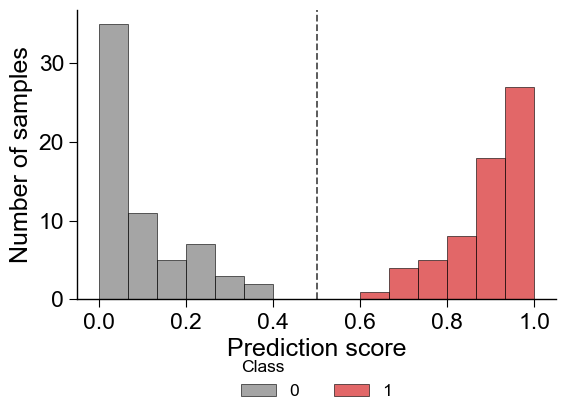

In [2]:
aap_plot.predict_group(data=scores, kind="hist", labels=labels, bins=15, thresholds=[0.5],
                           dict_color={1: "tab:red", 0: "tab:gray"}, figsize=(6, 4.5),
                           xlabel="Prediction score", ylabel="Number of samples")
plt.tight_layout()
plt.show()

**Confidence-banded histogram.** When scoring *unlabeled* candidates there is no class to separate by, so ``band=True`` instead colors each bar by the confidence band it falls into (delimited by ``thresholds``). Band colors are sampled from ``cmap`` unless an explicit ``colors`` list (one per band, low to high score) is given:

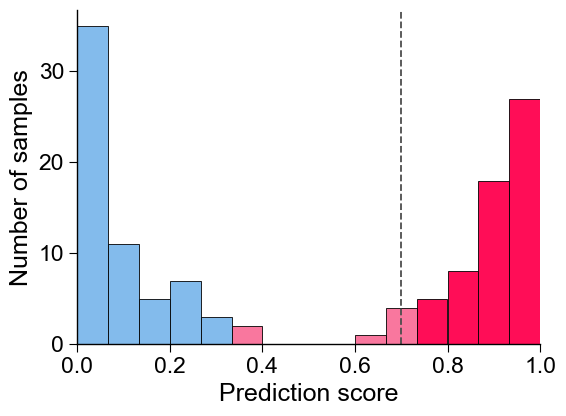

In [3]:
# Same scores, banded by confidence. Pass `band_colors` for explicit per-band colors
# (low->high score), or leave it out to sample them from `cmap`.
aap_plot.predict_group(data=scores, kind="hist", band=True, thresholds=[0.3, 0.7], bins=15,
                          band_colors=["#83BBEC", "#F9779E", "#FF0D57"], cmap="GnBu", figsize=(6, 4.5),
                          line_thresholds=[0.7],  # dashed line only at the upper cut-off (not the 0.3 split)
                          score_range=(0, 1),  # bin/x-limit over the full score range
                          xlabel="Prediction score", ylabel="Number of samples")
plt.tight_layout()
plt.show()

**Survival curve.** ``kind='cutoff'`` shows the percentage of samples scoring at or above each cutoff (``n_steps`` controls the resolution):

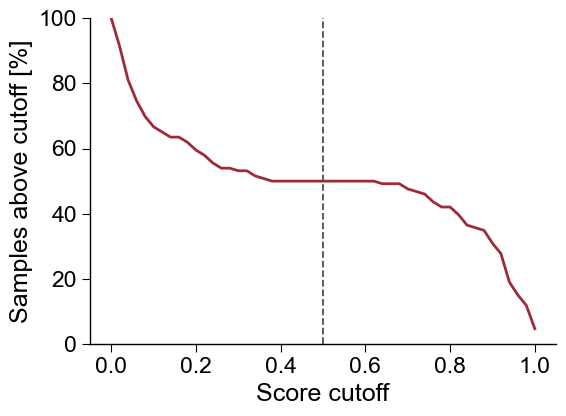

In [4]:
aap_plot.predict_group(data=scores, kind="cutoff", n_steps=51, thresholds=[0.5],
                           figsize=(6, 4.5), xlabel="Score cutoff",
                           ylabel="Samples above cutoff [%]")
plt.tight_layout()
plt.show()

**Grouped survival curve.** Passing ``labels`` draws one survival curve per group over a common cutoff grid (colored by ``dict_color``) — comparing how each class clears a score threshold:

/var/folders/sv/65tlch_10198qgmpwcp6408r0000gn/T/ipykernel_75025/251615570.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


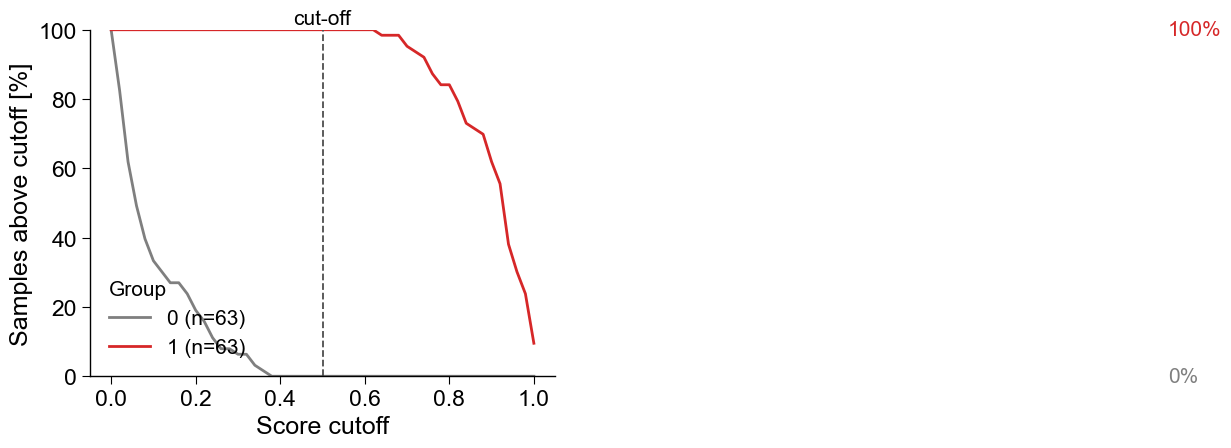

In [5]:
aap_plot.predict_group(data=scores, kind="cutoff", labels=labels,
                          dict_color={1: "tab:red", 0: "tab:gray"}, n_steps=51,
                          figsize=(6, 4.5), xlabel="Score cutoff",
                          ylabel="Samples above cutoff [%]", thresholds=[0.5],
                          annotate_at=0.5, show_n=True,
                          threshold_labels=["cut-off"], legend_loc="lower left")
plt.tight_layout()
plt.show()

**Two-predictor agreement.** ``kind='scatter'`` compares two predictors per sample; ``data`` is the x-axis and the required ``scores_y`` is the y-axis, with the ``y = x`` ``diagonal``, ``marker_size`` and ``dict_color``:

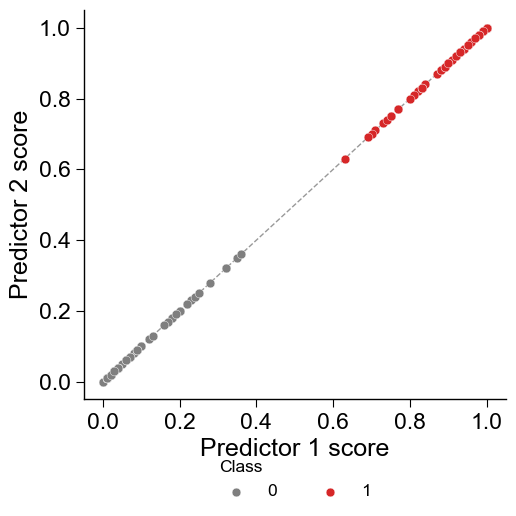

In [6]:
scores_y = aap.predict(df_seq, level="sequence",
                          list_parts=["tmd", "jmd_n_tmd_n", "tmd_c_jmd_c"])["score"].to_numpy()
aap_plot.predict_group(data=scores, kind="scatter", scores_y=scores_y, labels=labels,
                           dict_color={1: "tab:red", 0: "tab:gray"}, marker_size=40, diagonal=True,
                           xlabel="Predictor 1 score", ylabel="Predictor 2 score")
plt.tight_layout()
plt.show()

**Ranked candidates.** ``kind='ranking'`` ranks samples as horizontal bars colored by class, reading columns by name (``col_name``, ``col_score``, ``col_group``, ``col_std``) with ``colors``, confidence ``cutoffs``, ``top_n`` and ``ascending`` order:

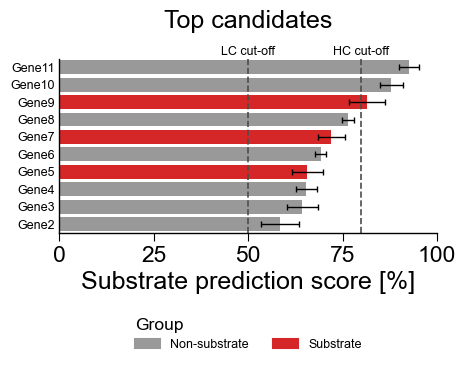

In [7]:
rng = np.random.RandomState(0)
df_rank = pd.DataFrame({
    "name":  [f"Gene{i}" for i in range(12)],
    "score": np.sort(rng.uniform(30, 95, 12)),
    "group": rng.choice(["Substrate", "Non-substrate"], 12),
    "std":   rng.uniform(1, 5, 12),
})
aap_plot.predict_group(data=df_rank, kind="ranking", col_name="name", col_score="score",
                           col_group="group", col_std="std",
                           dict_color={"Substrate": "tab:red", "Non-substrate": "0.6"},
                           thresholds=(50, 80), top_n=10, ascending=False, figsize=(5, 4),
                           xlabel="Substrate prediction score [%]", title="Top candidates")
plt.tight_layout()
plt.show()

**Faceted ranking.** ``panel_col`` splits the ranking into one panel per distinct value of that column, drawn side by side (here one panel per ``group``) — the multi-panel candidate leaderboard in a single call:

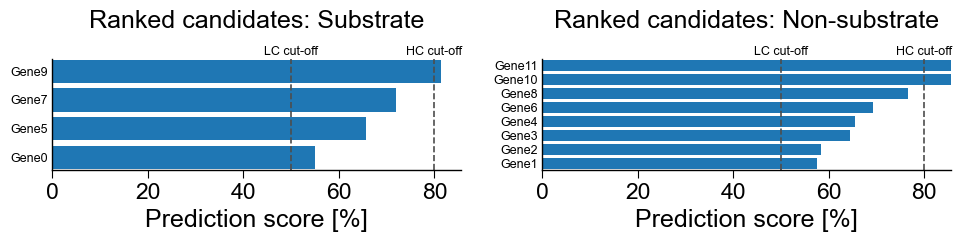

In [8]:
aap_plot.predict_group(data=df_rank, kind="ranking", col_name="name", col_score="score",
                          panel_col="group",
                          dict_color={"Substrate": "tab:red", "Non-substrate": "0.6"},
                          thresholds=(50, 80), title="Ranked candidates", legend_title="Prediction group")
plt.tight_layout()
plt.show()

**Named panels + hue clustering.** Instead of pre-computing a panel column, group the `col_group` values into named panels with a `panels={title: [groups]}` dict, and cluster the bars by class within each panel with `sort="group"` (ranked by score inside each class). Here the *Non-substrates* panel holds two classes, clustered:

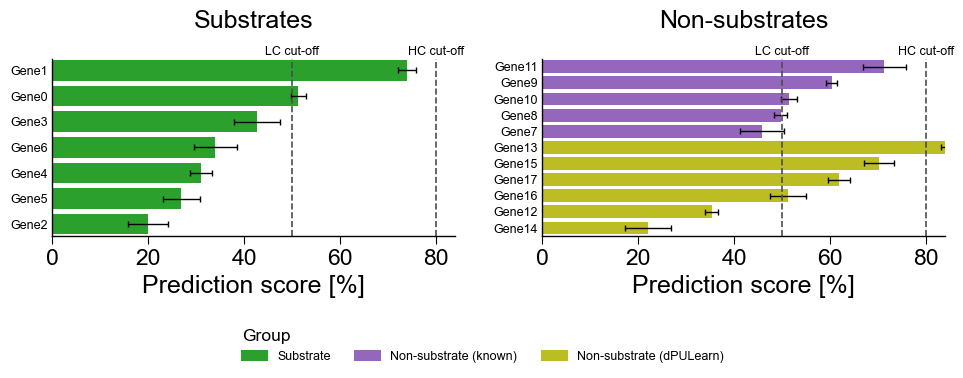

In [9]:
rng2 = np.random.RandomState(1)
df_rank3 = pd.DataFrame({
    "name":  [f"Gene{i}" for i in range(18)],
    "score": rng2.uniform(20, 95, 18),
    "group": ["Substrate"] * 7 + ["Non-substrate (known)"] * 5 + ["Non-substrate (dPULearn)"] * 6,
    "std":   rng2.uniform(1, 5, 18),
})
aap_plot.predict_group(data=df_rank3, kind="ranking", col_name="name", col_score="score",
                          col_group="group", col_std="std", sort="group",
                          panels={"Substrates":     ["Substrate"],
                                  "Non-substrates": ["Non-substrate (known)", "Non-substrate (dPULearn)"]},
                          dict_color={"Substrate": "tab:green", "Non-substrate (known)": "tab:purple",
                                  "Non-substrate (dPULearn)": "tab:olive"},
                          thresholds=(50, 80))
plt.tight_layout()
plt.show()

**Per-protein rank scatter.** ``kind='rank_scatter'`` is the standard sanity check for a deployed per-protein predictor: proteins are ranked by their maximum ``col_score`` (x-axis = rank, y-axis = score) and colored by ``col_group``. ``group_order`` fixes the color/legend order, ``dict_color`` overrides the canonical group colors (``substrate`` / ``non-substrate`` / ``hold-out`` default to the locked sample palette), ``thresholds`` draws horizontal cut-off lines, and ``marker_size`` sizes the points. This is the *population* view; contrast ``kind='ranking'`` above, which draws one horizontal bar per candidate.

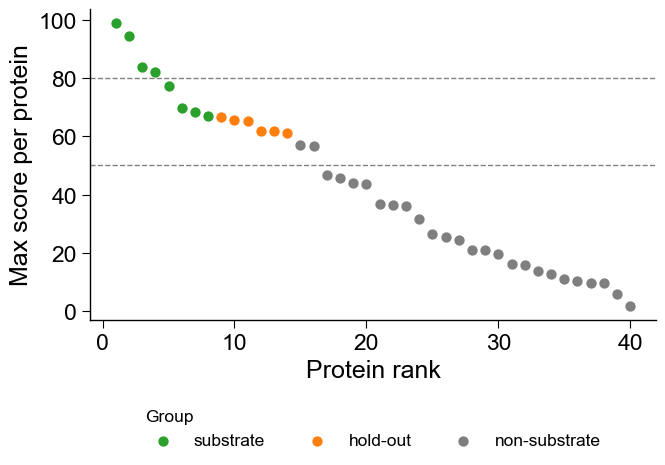

In [10]:
# Per-protein max score + group -> the deployed-predictor rank scatter (a different figure
# than kind="ranking": one point per protein, ranked, not one bar per candidate).
df_prot = pd.DataFrame({
    "score": np.sort(rng.uniform(0, 100, 40))[::-1],
    "group": ["substrate"] * 8 + ["hold-out"] * 6 + ["non-substrate"] * 26,
})
aap_plot.predict_group(data=df_prot, kind="rank_scatter", col_score="score", col_group="group",
                          group_order=["substrate", "hold-out", "non-substrate"],
                          dict_color={"substrate": "tab:green", "hold-out": "tab:orange",
                                      "non-substrate": "tab:gray"},
                          thresholds=[50, 80], marker_size=35,
                          xlabel="Protein rank", ylabel="Max score per protein")
plt.tight_layout()
plt.show()